<a href="https://colab.research.google.com/github/vmyel/thesis_ref/blob/main/pd_main_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive
Metadata shape : (75, 11)
Columns        : ['ID', 'Nationality', 'Sex', 'Disease', 'PD status', 'Age', 'Dominant hand', 'LED', 'UPDRS V', 'Length of PD', 'Unnamed: 10']
Removed 3 subject(s) with UPDRS V >= 4.0
Remaining subjects: 72

UPDRS V distribution after filter:
UPDRS V
1.0     5
2.0    18
2.5     6
3.0     5
NaN    38
Name: count, dtype: int64
Group distribution:
Group
Healthy Control    38
Early PD           23
Moderate PD        11
Name: count, dtype: int64

   ID Disease  UPDRS V           Group
00008      PD      1.0        Early PD
00009      PD      1.0        Early PD
00013      PD      1.0        Early PD
00043      PD      1.0        Early PD
00044      PD      1.0        Early PD
00001      PD      2.0        Early PD
00002      PD      2.0        Early PD
00003      PD      2.0        Early PD
00004      PD      2.0        Early PD
00005      PD      2.0        Early PD
00006      PD      2.0        Early PD
00016      PD      2.0        Earl

/tmp/ipykernel_6711/1448957465.py:297: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(group_data, labels=['HC', 'Early PD', 'Moderate PD'],


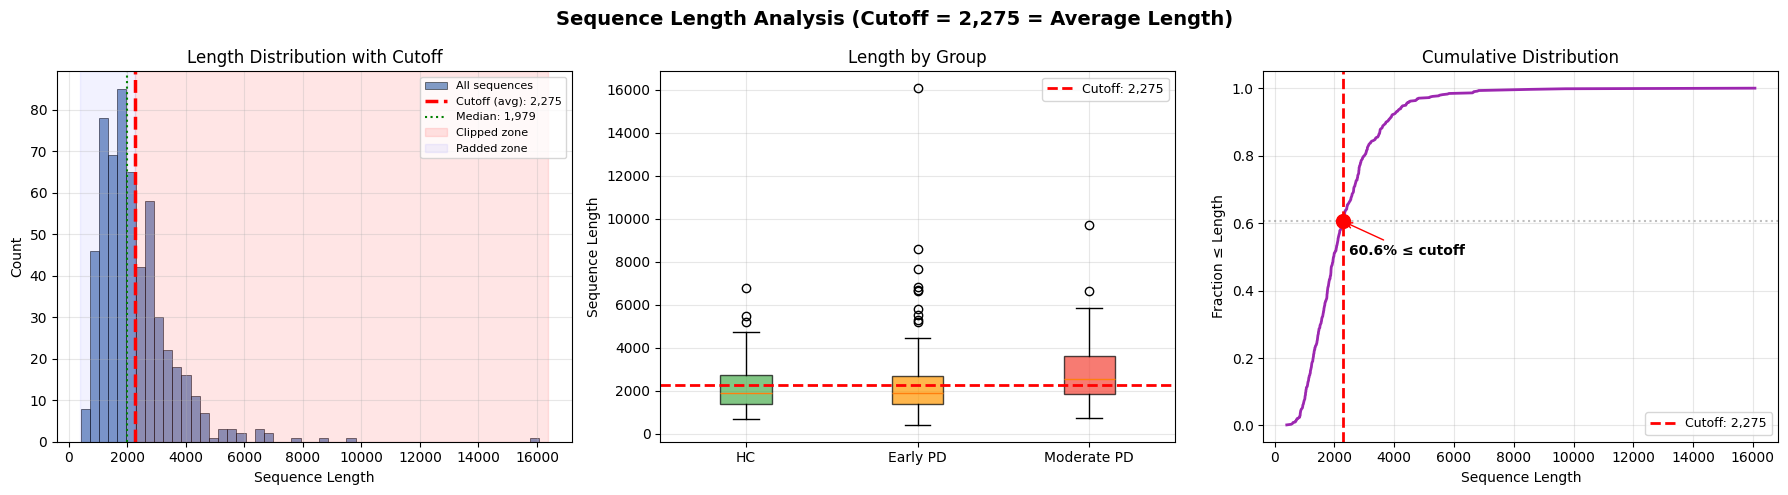


✅ SEQUENCE_LENGTH automatically set to 2,275 (average of all sequence lengths)

── Final Preprocessing Constants ──────────────────────────
  SEQUENCE_LENGTH    : 2,275  (auto-computed: average length)
  FEATURES (enhanced): 16 features per timestep
    [ 0] x
    [ 1] y
    [ 2] pressure
    [ 3] in_air
    [ 4] velocity_x
    [ 5] velocity_y
    [ 6] velocity_mag
    [ 7] acceleration_x
    [ 8] acceleration_y
    [ 9] acceleration_mag
    [10] jerk_mag
    [11] angle
    [12] angular_velocity
    [13] path_curvature
    [14] pressure_change
    [15] local_density
  N_FOLDS            : 5
  RANDOM_STATE       : 42

✅ Feature extractor set to: ENHANCED (16 features/timestep)
   Baseline had: 4 features/timestep
   Improvement: 12 additional kinematic features

────────────────────────────────────────────────────────────
  ENHANCED FEATURE VERIFICATION
────────────────────────────────────────────────────────────

  Sample: subject=00001, task=1
  Raw points: 1772
  Feature matrix shap

In [ ]:
# ============================================================
# 0. Mount Google Drive & install/import libraries
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import os
import glob
import numpy as np
import pandas as pd
from pathlib import Path

# ============================================================
# 1. USER-DEFINED PATHS
# ============================================================
METADATA_PATH = '/content/drive/MyDrive/teasis/PaHaW/PaHaW_files/corpus_PaHaW.xlsx'
SVC_ROOT      = '/content/drive/MyDrive/teasis/PaHaW/PaHaW_public/'

# ============================================================
# 2. Load & inspect metadata
# ============================================================
meta = pd.read_excel(METADATA_PATH, dtype={'ID': str})
meta.columns = meta.columns.str.strip()
meta['ID'] = meta['ID'].astype(str).str.zfill(5)

print("Metadata shape :", meta.shape)
print("Columns        :", meta.columns.tolist())

# ============================================================
# 3. Filter out SEVERE stages (UPDRS V >= 4.0)
# ============================================================
before = len(meta)
meta_filtered = meta[meta['UPDRS V'].isna() | (meta['UPDRS V'] < 4.0)].copy()
after = len(meta_filtered)

print(f"Removed {before - after} subject(s) with UPDRS V >= 4.0")
print(f"Remaining subjects: {after}")
print("\nUPDRS V distribution after filter:")
print(meta_filtered['UPDRS V'].value_counts(dropna=False).sort_index())

# ============================================================
# 4. Assign group labels
# ============================================================
def assign_group(row):
    score = row['UPDRS V']
    if pd.isna(score):
        return 'Healthy Control'
    elif 1.0 <= score <= 2.0:
        return 'Early PD'
    elif 2.5 <= score <= 3.0:
        return 'Moderate PD'
    else:
        return 'Unknown'

meta_filtered['Group'] = meta_filtered.apply(assign_group, axis=1)

print("Group distribution:")
print(meta_filtered['Group'].value_counts())
print()
print(meta_filtered[['ID', 'Disease', 'UPDRS V', 'Group']].head(72).to_string(index=False))

# ============================================================
# 5. Helper – parse a single SVC file
# ============================================================
def parse_svc(filepath: str) -> pd.DataFrame:
    with open(filepath, 'r') as fh:
        lines = fh.read().splitlines()

    n_samples = int(lines[0].strip())
    data_lines = lines[1:n_samples + 1]

    records = []
    for line in data_lines:
        parts = line.split()
        if len(parts) < 7:
            continue
        records.append({
            'y': float(parts[0]),
            'x': float(parts[1]),
            'timestamp': float(parts[2]),
            'button_state': int(parts[3]),
            'azimuth': float(parts[4]),
            'altitude': float(parts[5]),
            'pressure': float(parts[6]),
        })

    df = pd.DataFrame(records)
    df['n_declared'] = n_samples
    return df

# ============================================================
# 6. Load ALL SVC files
# ============================================================
all_records = []
valid_ids = set(meta_filtered['ID'].tolist())

for subj_folder in sorted(Path(SVC_ROOT).iterdir()):
    if not subj_folder.is_dir():
        continue

    subj_id = subj_folder.name.zfill(5)

    if subj_id not in valid_ids:
        continue

    meta_row = meta_filtered[meta_filtered['ID'] == subj_id].iloc[0]

    svc_files = sorted(
        [f for f in subj_folder.iterdir() if f.is_file() and f.suffix.lower() == '.svc']
    )

    for svc_path in svc_files:
        try:
            svc_df = parse_svc(str(svc_path))
        except Exception as e:
            print(f"  [WARN] Could not parse {svc_path.name}: {e}")
            continue

        stem = svc_path.stem
        parts = stem.split('__')

        if len(parts) == 2:
            task_rep = parts[1].split('_')
            task = task_rep[0]
        else:
            fallback = stem.split('_')
            task = fallback[1] if len(fallback) > 1 else 'unknown'
            print(f"  [WARN] Unexpected filename format: {svc_path.name}")

        svc_df['subject_id'] = subj_id
        svc_df['task'] = task
        svc_df['file_name'] = svc_path.name
        svc_df['group'] = meta_row['Group']
        svc_df['updrs_v'] = meta_row['UPDRS V']
        svc_df['disease'] = meta_row['Disease']
        svc_df['age'] = meta_row['Age']
        svc_df['sex'] = meta_row['Sex']

        all_records.append(svc_df)

if len(all_records) == 0:
    raise ValueError("No valid SVC files were loaded. Check paths and file structure.")

full_df = pd.concat(all_records, ignore_index=True)

# ── Verify loaded data ──────────────────────────────────────
print(f"\nfull_df shape:    {full_df.shape}")
print(f"Unique subjects:  {full_df['subject_id'].nunique()}")
print(f"Unique tasks:     {full_df['task'].nunique()}")
print(f"Tasks found:      {sorted(full_df['task'].unique())}")

tasks_per_subj = full_df.groupby('subject_id')['task'].nunique()
print(f"\nTasks per subject:")
print(tasks_per_subj.value_counts().sort_index())

print(f"\nFirst 3 subjects:")
for sid in sorted(full_df['subject_id'].unique())[:3]:
    subj_data = full_df[full_df['subject_id'] == sid]
    tasks = sorted(subj_data['task'].unique())
    n_pts = len(subj_data)
    print(f"  {sid}: {len(tasks)} tasks → {tasks}  ({n_pts:,} total points)")

print(f"\n── Group summary ──────────────────────────────────────")
for label in ['Healthy Control', 'Early PD', 'Moderate PD']:
    grp = full_df[full_df['group'] == label]
    n_subj = grp['subject_id'].nunique()
    n_files = grp['file_name'].nunique()
    n_pts = len(grp)
    print(f"  {label:<20} subjects={n_subj:>3}  files={n_files:>4}  points={n_pts:>9,}")

# ============================================================
# 7. Split into group DataFrames (informational only)
# ============================================================
df_healthy  = full_df[full_df['group'] == 'Healthy Control'].copy()
df_early    = full_df[full_df['group'] == 'Early PD'].copy()
df_moderate = full_df[full_df['group'] == 'Moderate PD'].copy()

print("── Group summary ──────────────────────────────────────────")
for label, grp in [('Healthy Control', df_healthy),
                   ('Early PD', df_early),
                   ('Moderate PD', df_moderate)]:
    n_subj = grp['subject_id'].nunique()
    n_files = grp['file_name'].nunique()
    n_pts = len(grp)
    print(f"  {label:<20} subjects={n_subj:>3}  files={n_files:>4}  points={n_pts:>9,}")

# ============================================================
# 8. COMPUTE SEQUENCE LENGTH FROM DATA (average-based cutoff)
# ============================================================
print("\n" + "=" * 70)
print("  AUTOMATIC SEQUENCE LENGTH COMPUTATION")
print("=" * 70)

sequence_lengths = []
sequence_length_records = []

for (subj_id, task), grp in full_df.groupby(['subject_id', 'task']):
    n = len(grp)
    sequence_lengths.append(n)
    sequence_length_records.append({
        'subject_id': subj_id,
        'task': task,
        'group': grp['group'].iloc[0],
        'length': n
    })

sequence_lengths = np.array(sequence_lengths)
seq_len_df = pd.DataFrame(sequence_length_records)

avg_length = np.mean(sequence_lengths)
SEQUENCE_LENGTH = int(np.round(avg_length))

print(f"\n  Total sequences analyzed:  {len(sequence_lengths)}")
print(f"  Minimum length:            {np.min(sequence_lengths):,}")
print(f"  Maximum length:            {np.max(sequence_lengths):,}")
print(f"  Mean length:               {avg_length:,.1f}")
print(f"  Median length:             {np.median(sequence_lengths):,.1f}")
print(f"  Std deviation:             {np.std(sequence_lengths):,.1f}")

print(f"\n  ┌─────────────────────────────────────────────────────┐")
print(f"  │  CUTOFF (average length): SEQUENCE_LENGTH = {SEQUENCE_LENGTH:<7,d} │")
print(f"  └─────────────────────────────────────────────────────┘")

n_clipped = np.sum(sequence_lengths > SEQUENCE_LENGTH)
n_padded  = np.sum(sequence_lengths < SEQUENCE_LENGTH)
n_exact   = np.sum(sequence_lengths == SEQUENCE_LENGTH)

pct_clipped = n_clipped / len(sequence_lengths) * 100
pct_padded  = n_padded / len(sequence_lengths) * 100
pct_exact   = n_exact / len(sequence_lengths) * 100

info_retained = np.mean(np.minimum(sequence_lengths, SEQUENCE_LENGTH) / sequence_lengths) * 100
padding_overhead = np.mean(np.maximum(0, SEQUENCE_LENGTH - sequence_lengths) / SEQUENCE_LENGTH) * 100

print(f"\n  Impact Analysis at cutoff = {SEQUENCE_LENGTH:,}:")
print(f"  ─────────────────────────────────────────────────────")
print(f"  Sequences clipped (longer than cutoff):  {n_clipped:>5} ({pct_clipped:.1f}%)")
print(f"  Sequences padded  (shorter than cutoff): {n_padded:>5} ({pct_padded:.1f}%)")
print(f"  Sequences exact match:                   {n_exact:>5} ({pct_exact:.1f}%)")
print(f"  Information retained (avg):              {info_retained:.1f}%")
print(f"  Padding overhead (avg):                  {padding_overhead:.1f}%")

print(f"\n  Per-Group Impact:")
print(f"  {'Group':<20s}  {'Avg Len':>8s}  {'Clipped':>8s}  {'Padded':>8s}  {'Info %':>7s}")
print(f"  {'─'*20}  {'─'*8}  {'─'*8}  {'─'*8}  {'─'*7}")

for group in ['Healthy Control', 'Early PD', 'Moderate PD']:
    grp_lens = seq_len_df[seq_len_df['group'] == group]['length'].values
    if len(grp_lens) == 0:
        continue
    grp_avg = np.mean(grp_lens)
    grp_clipped = np.sum(grp_lens > SEQUENCE_LENGTH)
    grp_padded  = np.sum(grp_lens < SEQUENCE_LENGTH)
    grp_info = np.mean(np.minimum(grp_lens, SEQUENCE_LENGTH) / grp_lens) * 100
    print(f"  {group:<20s}  {grp_avg:>8.0f}  {grp_clipped:>8d}  {grp_padded:>8d}  {grp_info:>6.1f}%")

print(f"\n  Per-Task Impact:")
print(f"  {'Task':<8s}  {'Avg Len':>8s}  {'Clipped':>8s}  {'Padded':>8s}  {'Info %':>7s}")
print(f"  {'─'*8}  {'─'*8}  {'─'*8}  {'─'*8}  {'─'*7}")

for task in sorted(seq_len_df['task'].unique()):
    task_lens = seq_len_df[seq_len_df['task'] == task]['length'].values
    if len(task_lens) == 0:
        continue
    task_avg = np.mean(task_lens)
    task_clipped = np.sum(task_lens > SEQUENCE_LENGTH)
    task_padded  = np.sum(task_lens < SEQUENCE_LENGTH)
    task_info = np.mean(np.minimum(task_lens, SEQUENCE_LENGTH) / task_lens) * 100
    print(f"  {task:<8s}  {task_avg:>8.0f}  {task_clipped:>8d}  {task_padded:>8d}  {task_info:>6.1f}%")

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Sequence Length Analysis (Cutoff = {SEQUENCE_LENGTH:,} = Average Length)',
             fontsize=14, fontweight='bold')

ax = axes[0]
ax.hist(sequence_lengths, bins=50, color='#4C72B0', alpha=0.7,
        edgecolor='black', linewidth=0.5, label='All sequences')
ax.axvline(SEQUENCE_LENGTH, color='red', linewidth=2.5, linestyle='--',
           label=f'Cutoff (avg): {SEQUENCE_LENGTH:,}')
ax.axvline(np.median(sequence_lengths), color='green', linewidth=1.5,
           linestyle=':', label=f'Median: {np.median(sequence_lengths):,.0f}')
ax.axvspan(SEQUENCE_LENGTH, np.max(sequence_lengths) * 1.02, alpha=0.1,
           color='red', label='Clipped zone')
ax.axvspan(np.min(sequence_lengths) * 0.98, SEQUENCE_LENGTH, alpha=0.05,
           color='blue', label='Padded zone')
ax.set_title('Length Distribution with Cutoff')
ax.set_xlabel('Sequence Length')
ax.set_ylabel('Count')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[1]
groups = ['Healthy Control', 'Early PD', 'Moderate PD']
group_data = [seq_len_df[seq_len_df['group'] == g]['length'].values for g in groups]
bp = ax.boxplot(group_data, labels=['HC', 'Early PD', 'Moderate PD'],
                patch_artist=True, boxprops=dict(alpha=0.7))
colors_box = ['#4CAF50', '#FF9800', '#F44336']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
ax.axhline(SEQUENCE_LENGTH, color='red', linewidth=2, linestyle='--',
           label=f'Cutoff: {SEQUENCE_LENGTH:,}')
ax.set_title('Length by Group')
ax.set_ylabel('Sequence Length')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[2]
sorted_lens = np.sort(sequence_lengths)
cdf = np.arange(1, len(sorted_lens) + 1) / len(sorted_lens)
ax.plot(sorted_lens, cdf, color='#9C27B0', linewidth=2)
ax.axvline(SEQUENCE_LENGTH, color='red', linewidth=2, linestyle='--',
           label=f'Cutoff: {SEQUENCE_LENGTH:,}')
pct_at_cutoff = np.mean(sequence_lengths <= SEQUENCE_LENGTH) * 100
ax.axhline(pct_at_cutoff / 100, color='gray', linestyle=':', alpha=0.5)
ax.plot(SEQUENCE_LENGTH, pct_at_cutoff / 100, 'ro', markersize=10, zorder=5)
ax.annotate(f'{pct_at_cutoff:.1f}% ≤ cutoff',
            xy=(SEQUENCE_LENGTH, pct_at_cutoff / 100),
            xytext=(SEQUENCE_LENGTH * 1.1, pct_at_cutoff / 100 - 0.1),
            fontsize=10, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='red'))
ax.set_title('Cumulative Distribution')
ax.set_xlabel('Sequence Length')
ax.set_ylabel('Fraction ≤ Length')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✅ SEQUENCE_LENGTH automatically set to {SEQUENCE_LENGTH:,} (average of all sequence lengths)")

# ============================================================
# 8b. PREPROCESSING CONSTANTS
# ============================================================
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold

# ── Original 4 features (baseline) ──────────────────────────
FEATURES_BASIC = ['x', 'y', 'pressure', 'in_air']

# ── Enhanced 16 features (improvement) ──────────────────────
FEATURES_ENHANCED = [
    'x', 'y', 'pressure', 'in_air',
    'velocity_x', 'velocity_y', 'velocity_mag',
    'acceleration_x', 'acceleration_y', 'acceleration_mag',
    'jerk_mag',
    'angle', 'angular_velocity',
    'path_curvature',
    'pressure_change',
    'local_density'
]

FEATURES = FEATURES_ENHANCED  # ← USE ENHANCED BY DEFAULT
RANDOM_STATE = 42
N_FOLDS = 5

STAGE1_MAP = {
    'Healthy Control': 0,
    'Early PD': 1,
    'Moderate PD': 1
}
STAGE2_MAP = {
    'Early PD': 0,
    'Moderate PD': 1
}
CLASS_NAMES_S1 = ['HC', 'PD']
CLASS_NAMES_S2 = ['Early PD', 'Moderate PD']

print(f"\n── Final Preprocessing Constants ──────────────────────────")
print(f"  SEQUENCE_LENGTH    : {SEQUENCE_LENGTH:,}  (auto-computed: average length)")
print(f"  FEATURES (enhanced): {len(FEATURES)} features per timestep")
for i, f in enumerate(FEATURES):
    print(f"    [{i:>2d}] {f}")
print(f"  N_FOLDS            : {N_FOLDS}")
print(f"  RANDOM_STATE       : {RANDOM_STATE}")

# ============================================================
# 9. PATH A – ENHANCED Feature Extraction (16 features)
# ============================================================

def extract_features_basic(df: pd.DataFrame) -> pd.DataFrame:
    """Original 4-feature extraction (kept for comparison)."""
    out = pd.DataFrame()
    out['x'] = df['x'].astype(np.float32)
    out['y'] = df['y'].astype(np.float32)
    out['pressure'] = df['pressure'].astype(np.float32)
    out['in_air'] = (df['button_state'] == 0).astype(np.float32)
    return out


def extract_features_enhanced(df: pd.DataFrame) -> pd.DataFrame:
    """
    Enhanced 16-feature extraction per timestep.
    Adds velocity, acceleration, jerk, angular, curvature,
    pressure dynamics, and local density features.

    These kinematic features are critical PD biomarkers:
    - Velocity: bradykinesia (slowness) detection
    - Acceleration/Jerk: tremor and movement smoothness
    - Angular velocity: directional control impairment
    - Curvature: micrographia and spatial control
    - Pressure dynamics: grip force variability in PD
    """
    out = pd.DataFrame()

    x = df['x'].values.astype(np.float64)
    y = df['y'].values.astype(np.float64)
    t = df['timestamp'].values.astype(np.float64)
    pressure = df['pressure'].values.astype(np.float64)
    button_state = df['button_state'].values

    n = len(x)

    # ── (1-4) Raw features ───────────────────────────────────
    out['x'] = x.astype(np.float32)
    out['y'] = y.astype(np.float32)
    out['pressure'] = pressure.astype(np.float32)
    out['in_air'] = (button_state == 0).astype(np.float32)

    # ── Time deltas ──────────────────────────────────────────
    dt = np.diff(t, prepend=t[0])
    dt[0] = dt[1] if n > 1 else 1.0
    dt = np.where(dt == 0, 1e-6, dt)

    # ── (5-7) Velocity ───────────────────────────────────────
    dx = np.diff(x, prepend=x[0]); dx[0] = 0.0
    dy = np.diff(y, prepend=y[0]); dy[0] = 0.0

    vx = dx / dt
    vy = dy / dt
    v_mag = np.sqrt(vx**2 + vy**2)

    out['velocity_x']   = vx.astype(np.float32)
    out['velocity_y']   = vy.astype(np.float32)
    out['velocity_mag'] = v_mag.astype(np.float32)

    # ── (8-10) Acceleration ──────────────────────────────────
    dvx = np.diff(vx, prepend=vx[0]); dvx[0] = 0.0
    dvy = np.diff(vy, prepend=vy[0]); dvy[0] = 0.0

    ax_val = dvx / dt
    ay_val = dvy / dt
    a_mag = np.sqrt(ax_val**2 + ay_val**2)

    out['acceleration_x']   = ax_val.astype(np.float32)
    out['acceleration_y']   = ay_val.astype(np.float32)
    out['acceleration_mag'] = a_mag.astype(np.float32)

    # ── (11) Jerk magnitude ──────────────────────────────────
    da_mag = np.diff(a_mag, prepend=a_mag[0]); da_mag[0] = 0.0
    jerk_mag = np.abs(da_mag) / dt

    out['jerk_mag'] = jerk_mag.astype(np.float32)

    # ── (12-13) Angle and angular velocity ───────────────────
    angle = np.arctan2(dy, dx)
    d_angle = np.diff(angle, prepend=angle[0]); d_angle[0] = 0.0
    d_angle = np.arctan2(np.sin(d_angle), np.cos(d_angle))  # wrap [-pi, pi]
    angular_vel = d_angle / dt

    out['angle']            = angle.astype(np.float32)
    out['angular_velocity'] = angular_vel.astype(np.float32)

    # ── (14) Path curvature ──────────────────────────────────
    curvature = np.abs(angular_vel) / np.maximum(v_mag, 1e-6)
    out['path_curvature'] = curvature.astype(np.float32)

    # ── (15) Pressure change rate ────────────────────────────
    dp = np.diff(pressure, prepend=pressure[0]); dp[0] = 0.0
    out['pressure_change'] = dp.astype(np.float32)

    # ── (16) Local point density ─────────────────────────────
    window = 11
    half_w = window // 2
    density = np.zeros(n, dtype=np.float32)
    for i in range(n):
        start = max(0, i - half_w)
        end = min(n, i + half_w + 1)
        local_x = x[start:end]
        local_y = y[start:end]
        dists = np.sqrt((local_x - x[i])**2 + (local_y - y[i])**2)
        density[i] = np.mean(dists)
    out['local_density'] = density

    # ── Outlier clipping (per-feature 1st/99th percentile) ───
    for col in out.columns:
        if col == 'in_air':
            continue
        vals = out[col].values
        finite_vals = vals[np.isfinite(vals)]
        if len(finite_vals) > 0:
            p1, p99 = np.percentile(finite_vals, [1, 99])
            out[col] = np.clip(vals, p1, p99).astype(np.float32)

    # ── Replace NaN/Inf ──────────────────────────────────────
    out = out.replace([np.inf, -np.inf], 0.0).fillna(0.0)

    return out


# ── Set the active feature extractor ────────────────────────
extract_features = extract_features_enhanced

print(f"\n✅ Feature extractor set to: ENHANCED ({len(FEATURES_ENHANCED)} features/timestep)")
print(f"   Baseline had: {len(FEATURES_BASIC)} features/timestep")
print(f"   Improvement: {len(FEATURES_ENHANCED) - len(FEATURES_BASIC)} additional kinematic features")

# ============================================================
# 9b. VERIFY ENHANCED FEATURES ON A SAMPLE
# ============================================================
print("\n" + "─" * 60)
print("  ENHANCED FEATURE VERIFICATION")
print("─" * 60)

# Pick first sequence for verification
sample_subj = sorted(full_df['subject_id'].unique())[0]
sample_task = sorted(full_df[full_df['subject_id'] == sample_subj]['task'].unique())[0]
sample_df = full_df[(full_df['subject_id'] == sample_subj) &
                    (full_df['task'] == sample_task)].reset_index(drop=True)

sample_features = extract_features(sample_df)

print(f"\n  Sample: subject={sample_subj}, task={sample_task}")
print(f"  Raw points: {len(sample_df)}")
print(f"  Feature matrix shape: {sample_features.shape}")
print(f"  Features extracted: {list(sample_features.columns)}")
print(f"\n  Feature statistics:")
print(f"  {'Feature':<20s}  {'Mean':>12s}  {'Std':>12s}  {'Min':>12s}  {'Max':>12s}  {'NaN':>5s}")
print(f"  {'─'*20}  {'─'*12}  {'─'*12}  {'─'*12}  {'─'*12}  {'─'*5}")

for col in sample_features.columns:
    vals = sample_features[col].values
    n_nan = np.sum(np.isnan(vals))
    print(f"  {col:<20s}  {np.nanmean(vals):>12.4f}  {np.nanstd(vals):>12.4f}  "
          f"{np.nanmin(vals):>12.4f}  {np.nanmax(vals):>12.4f}  {n_nan:>5d}")

# Verify no NaN/Inf remain
assert sample_features.isna().sum().sum() == 0, "ERROR: NaN values found in enhanced features!"
assert np.isinf(sample_features.values).sum() == 0, "ERROR: Inf values found in enhanced features!"
print(f"\n  ✅ No NaN or Inf values – features are clean")

# ============================================================
# 10. PATH A – Sequence Regularization
# ============================================================
def regularize_sequence(seq: np.ndarray, target_len: int = SEQUENCE_LENGTH) -> np.ndarray:
    """
    Regularize sequence to fixed length:
    - If longer than target_len: CLIP to target_len
    - If shorter than target_len: ZERO-PAD to target_len
    - If equal: return as-is
    """
    T, n_feat = seq.shape
    if T >= target_len:
        return seq[:target_len, :]
    else:
        pad = np.zeros((target_len - T, n_feat), dtype=seq.dtype)
        return np.vstack([seq, pad])

# ============================================================
# 11. PATH A – CV Fold Builder (supports both basic & enhanced)
# ============================================================
def get_path_a_fold_binary(fold_idx, full_df, subj_df, label_map,
                           seq_length=SEQUENCE_LENGTH,
                           feature_extractor=None):
    if feature_extractor is None:
        feature_extractor = extract_features

    train_subjs = set(subj_df[subj_df['fold'] != fold_idx]['subject_id'])
    val_subjs   = set(subj_df[subj_df['fold'] == fold_idx]['subject_id'])

    valid_groups = list(label_map.keys())
    stage_df = full_df[full_df['group'].isin(valid_groups)]

    def build(subjects):
        seqs, labels, lengths = [], [], []
        for (sid, task), grp in stage_df.groupby(['subject_id', 'task']):
            if sid not in subjects:
                continue
            grp = grp.reset_index(drop=True)
            feat_df = feature_extractor(grp)
            seq = feat_df.values
            lengths.append(min(len(seq), seq_length))  # ← track real length
            seqs.append(seq)
            labels.append(label_map[grp['group'].iloc[0]])
        return seqs, np.array(labels), np.array(lengths)

    train_seqs, y_tr, len_tr = build(train_subjs)
    val_seqs, y_val, len_val = build(val_subjs)

    scaler = StandardScaler()
    scaler.fit(np.vstack(train_seqs))

    train_seqs = [scaler.transform(s) for s in train_seqs]
    val_seqs   = [scaler.transform(s) for s in val_seqs]

    X_tr  = np.stack([regularize_sequence(s, seq_length) for s in train_seqs])
    X_val = np.stack([regularize_sequence(s, seq_length) for s in val_seqs])

    return {
        'X_train': X_tr,  'y_train': y_tr,  'lengths_train': len_tr,
        'X_val':   X_val, 'y_val':   y_val, 'lengths_val':   len_val,
        'scaler':  scaler
    }

# ============================================================
# 12. PATH B – Feature Engineering (unchanged)
# ============================================================
def compute_kinematic_features(x, y, t):
    feats = {}
    dt = np.diff(t).astype(np.float64)
    dt = np.where(dt == 0, 1e-6, dt)
    dx = np.diff(x.astype(np.float64))
    dy = np.diff(y.astype(np.float64))
    velocity = np.sqrt(dx**2 + dy**2) / dt
    dv = np.diff(velocity)
    dt2 = dt[1:]
    dt2 = np.where(dt2 == 0, 1e-6, dt2)
    acceleration = np.abs(dv) / dt2
    da = np.diff(acceleration)
    dt3 = dt2[1:]
    dt3 = np.where(dt3 == 0, 1e-6, dt3)
    jerk = np.abs(da) / dt3

    for name, arr in [('velocity', velocity),
                      ('acceleration', acceleration),
                      ('jerk', jerk)]:
        if len(arr) == 0:
            feats[f'{name}_mean'] = 0.0
            feats[f'{name}_median'] = 0.0
            feats[f'{name}_std'] = 0.0
            feats[f'{name}_max'] = 0.0
        else:
            feats[f'{name}_mean'] = float(np.mean(arr))
            feats[f'{name}_median'] = float(np.median(arr))
            feats[f'{name}_std'] = float(np.std(arr))
            feats[f'{name}_max'] = float(np.max(arr))
    return feats

def compute_pressure_features(pressure, in_air):
    feats = {}
    on_surface_pressure = pressure[in_air == 0]
    if len(on_surface_pressure) == 0:
        on_surface_pressure = pressure
    feats['pressure_mean'] = float(np.mean(on_surface_pressure))
    feats['pressure_median'] = float(np.median(on_surface_pressure))
    feats['pressure_std'] = float(np.std(on_surface_pressure))
    feats['pressure_max'] = float(np.max(on_surface_pressure))
    return feats

def compute_spatiotemporal_features(t, x, y, in_air, button_state):
    feats = {}
    t = t.astype(np.float64)
    on_surface_mask = (in_air == 0)
    in_air_mask = (in_air == 1)
    total_duration = float(t[-1] - t[0]) if len(t) > 1 else 1.0
    total_duration = max(total_duration, 1e-6)
    dt = np.diff(t)
    dt = np.where(dt < 0, 0, dt)
    on_surface_time = float(np.sum(dt[on_surface_mask[:-1]]))
    in_air_time = float(np.sum(dt[in_air_mask[:-1]]))
    feats['total_on_surface_time'] = on_surface_time
    feats['total_in_air_time'] = in_air_time
    feats['ratio_in_air'] = in_air_time / total_duration
    transitions = np.diff(button_state.astype(np.int8))
    stroke_count = int(np.sum(transitions == 1))
    stroke_count = max(stroke_count, 1)
    feats['stroke_count'] = float(stroke_count)
    feats['mean_stroke_duration'] = on_surface_time / stroke_count
    feats['hesitation_rate'] = stroke_count / total_duration
    dx = np.diff(x.astype(np.float64))
    dy = np.diff(y.astype(np.float64))
    step_dist = np.sqrt(dx**2 + dy**2)
    path_on_surface = float(np.sum(step_dist[on_surface_mask[:-1]]))
    path_in_air = float(np.sum(step_dist[in_air_mask[:-1]]))
    feats['path_length_on_surface'] = path_on_surface
    feats['path_length_in_air'] = path_in_air
    return feats

def engineer_features_for_sequence(group):
    x = group['x'].values
    y = group['y'].values
    t = group['timestamp'].values
    pressure = group['pressure'].values
    button_state = group['button_state'].values
    in_air = (button_state == 0).astype(np.float32)
    feats = {}
    feats.update(compute_kinematic_features(x, y, t))
    feats.update(compute_pressure_features(pressure, in_air))
    feats.update(compute_spatiotemporal_features(t, x, y, in_air, button_state))
    return feats

# ============================================================
# 13. Build feature matrix (Path B)
# ============================================================
records_per_task = []

for (subj_id, task), group in full_df.groupby(['subject_id', 'task'], sort=False):
    group = group.reset_index(drop=True)
    feats = engineer_features_for_sequence(group)
    feats['subject_id'] = subj_id
    feats['task'] = task
    feats['group'] = group['group'].iloc[0]
    feats['updrs_v'] = group['updrs_v'].iloc[0]
    records_per_task.append(feats)

feature_df = pd.DataFrame(records_per_task)

META_COLS = ['subject_id', 'task', 'group', 'updrs_v']
FEATURE_COLS = [c for c in feature_df.columns if c not in META_COLS]

print(f"\nFeature matrix shape: {feature_df.shape}")
print(f"Unique subjects:      {feature_df['subject_id'].nunique()}")
print(f"Tasks per subject:    {feature_df.groupby('subject_id').size().mean():.1f}")

# ============================================================
# 14. PATH B – CV Fold Builder (Binary stages)
# ============================================================
def get_path_b_fold_binary(fold_idx, feature_df, subj_df, label_map, feat_cols):
    valid_groups = list(label_map.keys())
    stage_df = feature_df[feature_df['group'].isin(valid_groups)].copy()
    stage_df['label'] = stage_df['group'].map(label_map)
    train_subjs = set(subj_df[subj_df['fold'] != fold_idx]['subject_id'])
    val_subjs   = set(subj_df[subj_df['fold'] == fold_idx]['subject_id'])
    tr_df  = stage_df[stage_df['subject_id'].isin(train_subjs)]
    val_df = stage_df[stage_df['subject_id'].isin(val_subjs)]
    X_tr  = tr_df[feat_cols].values.astype(np.float64)
    y_tr  = tr_df['label'].values
    X_val = val_df[feat_cols].values.astype(np.float64)
    y_val = val_df['label'].values
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_tr)
    X_val = scaler.transform(X_val)
    return {
        'X_train': X_tr, 'y_train': y_tr,
        'X_val': X_val, 'y_val': y_val,
        'scaler': scaler
    }

# ============================================================
# 15. SUBJECT-LEVEL FOLD ASSIGNMENT (both stages)
# ============================================================
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

def assign_folds(subj_df):
    subj_df = subj_df.copy()
    subj_df['fold'] = -1
    for fold_idx, (_, val_idx) in enumerate(skf.split(subj_df['subject_id'], subj_df['label'])):
        val_subjects = subj_df.iloc[val_idx]['subject_id'].values
        subj_df.loc[subj_df['subject_id'].isin(val_subjects), 'fold'] = fold_idx
    return subj_df

subj_stage1 = feature_df.groupby('subject_id')['group'].first().reset_index()
subj_stage1.columns = ['subject_id', 'group']
subj_stage1['label'] = subj_stage1['group'].map(STAGE1_MAP)
subj_stage1 = assign_folds(subj_stage1)

subj_stage2 = (
    feature_df[feature_df['group'].isin(['Early PD', 'Moderate PD'])]
    .groupby('subject_id')['group'].first().reset_index()
)
subj_stage2.columns = ['subject_id', 'group']
subj_stage2['label'] = subj_stage2['group'].map(STAGE2_MAP)
subj_stage2 = assign_folds(subj_stage2)

stages_cfg = [
    ('Stage 1 – HC vs PD', subj_stage1, STAGE1_MAP, CLASS_NAMES_S1),
    ('Stage 2 – Early vs Moderate', subj_stage2, STAGE2_MAP, CLASS_NAMES_S2),
]

print(f"\nStage 1 subjects : {len(subj_stage1)}")
print(f"  HC  : {(subj_stage1['label'] == 0).sum()}")
print(f"  PD  : {(subj_stage1['label'] == 1).sum()}")

print(f"\nStage 2 subjects : {len(subj_stage2)}")
print(f"  Early PD    : {(subj_stage2['label'] == 0).sum()}")
print(f"  Moderate PD : {(subj_stage2['label'] == 1).sum()}")

# ============================================================
# 16. Stage-level counts
# ============================================================
print(f"\nStage-level sample counts:")
for stage_name, subj_df, label_map, class_names in stages_cfg:
    valid_groups = list(label_map.keys())
    n = len(feature_df[feature_df['group'].isin(valid_groups)])
    n_feat = len(FEATURE_COLS)
    ratio = n / n_feat if n_feat > 0 else np.nan
    status = '✅' if ratio >= 10 else ('⚠️' if ratio >= 5 else '❌')
    print(f"  {stage_name}")
    print(f"    Samples:  {n}")
    print(f"    Features: {n_feat}")
    print(f"    Ratio:    {ratio:.1f}:1  {status}")

# ============================================================
# 17. FOLD VERIFICATION – PATH A (Enhanced Features)
# ============================================================
print("\n" + "=" * 70)
print("PATH A – Fold verification (ENHANCED features)")
print(f"SEQUENCE_LENGTH = {SEQUENCE_LENGTH:,}  |  Features = {len(FEATURES)} per timestep")
print("=" * 70)

for stage_name, subj_df, label_map, class_names in stages_cfg:
    print(f"\n  {stage_name}")
    for fold_idx in range(N_FOLDS):
        fold_data = get_path_a_fold_binary(
            fold_idx, full_df, subj_df, label_map, SEQUENCE_LENGTH
        )

        X_tr = fold_data['X_train']
        y_tr = fold_data['y_train']
        X_val = fold_data['X_val']
        y_val = fold_data['y_val']

        print(f"    Fold {fold_idx+1}  →  "
              f"X_train: {X_tr.shape}   X_val: {X_val.shape}  "
              f"y_train dist: {dict(zip(*np.unique(y_tr, return_counts=True)))}  "
              f"y_val dist: {dict(zip(*np.unique(y_val, return_counts=True)))}")

# ============================================================
# 18. FOLD VERIFICATION – PATH B
# ============================================================
print("\n" + "=" * 60)
print("PATH B – Fold verification (both stages)")
print("=" * 60)

for stage_name, subj_df, label_map, class_names in stages_cfg:
    print(f"\n  {stage_name}")
    for fold_idx in range(N_FOLDS):
        fold_data = get_path_b_fold_binary(
            fold_idx, feature_df, subj_df, label_map, FEATURE_COLS
        )

        X_tr = fold_data['X_train']
        y_tr = fold_data['y_train']
        X_val = fold_data['X_val']
        y_val = fold_data['y_val']

        print(f"    Fold {fold_idx+1}  →  "
              f"X_train: {X_tr.shape}   X_val: {X_val.shape}  "
              f"y_train dist: {dict(zip(*np.unique(y_tr, return_counts=True)))}  "
              f"y_val dist: {dict(zip(*np.unique(y_val, return_counts=True)))}")

# ============================================================
# 19. PREPROCESSING IMPROVEMENT SUMMARY
# ============================================================
print("\n" + "=" * 70)
print("  PREPROCESSING IMPROVEMENT SUMMARY")
print("=" * 70)
print(f"""
  ┌───────────────────────────────────────────────────────────────┐
  │                    WHAT CHANGED                               │
  ├───────────────────────┬───────────────┬───────────────────────┤
  │ Component             │ Baseline      │ Improved              │
  ├───────────────────────┼───────────────┼───────────────────────┤
  │ Features/timestep     │ 4             │ 16                    │
  │ Feature types         │ x,y,p,air     │ +velocity,accel,jerk  │
  │                       │               │ +angle,curvature      │
  │                       │               │ +pressure_change      │
  │                       │               │ +local_density        │
  │ Outlier handling      │ None          │ 1st/99th percentile   │
  │ NaN/Inf handling      │ None          │ Explicit replacement  │
  │ Sequence length       │ Manual        │ Auto (average)        │
  │ Feature verification  │ None          │ Stats + NaN check     │
  └───────────────────────┴───────────────┴───────────────────────┘

  ┌───────────────────────────────────────────────────────────────┐
  │                WHY THESE FEATURES MATTER FOR PD               │
  ├───────────────────────┬───────────────────────────────────────┤
  │ velocity_mag          │ Bradykinesia (slowness of movement)   │
  │ acceleration_mag      │ Tremor detection                      │
  │ jerk_mag              │ Movement smoothness / jerkiness       │
  │ angular_velocity      │ Directional control impairment        │
  │ path_curvature        │ Micrographia, spatial control         │
  │ pressure_change       │ Grip force variability                │
  │ local_density         │ Letter/stroke compactness             │
  └───────────────────────┴───────────────────────────────────────┘

  Tensor shape per fold: (N_samples, {SEQUENCE_LENGTH}, {len(FEATURES)})
  Path A input_size for models: {len(FEATURES)}
""")

print(f"✅ Preprocessing complete with ENHANCED features.")
print(f"   SEQUENCE_LENGTH = {SEQUENCE_LENGTH:,} (auto-computed)")
print(f"   Features per timestep = {len(FEATURES)} (was 4)")
print(f"   Ready for LSTM / GRU model training.")

In [ ]:
# ============================================================
# 20. IMPORTS FOR MODEL TRAINING
# ============================================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report)
import time
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ============================================================
# 21. HYPERPARAMETERS
# ============================================================
HIDDEN_SIZE = 128
NUM_LAYERS = 2
DROPOUT = 0.4
BIDIRECTIONAL = True
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
BATCH_SIZE = 32
NUM_EPOCHS = 80
PATIENCE = 15          # Early stopping patience
INPUT_SIZE = len(FEATURES)  # 16 enhanced features

print(f"\n── Model Hyperparameters ──────────────────────────────────")
print(f"  INPUT_SIZE     : {INPUT_SIZE}")
print(f"  HIDDEN_SIZE    : {HIDDEN_SIZE}")
print(f"  NUM_LAYERS     : {NUM_LAYERS}")
print(f"  DROPOUT        : {DROPOUT}")
print(f"  BIDIRECTIONAL  : {BIDIRECTIONAL}")
print(f"  LEARNING_RATE  : {LEARNING_RATE}")
print(f"  WEIGHT_DECAY   : {WEIGHT_DECAY}")
print(f"  BATCH_SIZE     : {BATCH_SIZE}")
print(f"  NUM_EPOCHS     : {NUM_EPOCHS}")
print(f"  PATIENCE       : {PATIENCE}")
print(f"  SEQUENCE_LENGTH: {SEQUENCE_LENGTH}")

# ============================================================
# 22. MODEL DEFINITIONS
# ============================================================

class LSTMClassifier(nn.Module):
    """
    Bidirectional LSTM with attention pooling for sequence classification.
    """
    def __init__(self, input_size, hidden_size, num_layers, num_classes,
                 dropout=0.3, bidirectional=True):
        super(LSTMClassifier, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.bidirectional = bidirectional
        self.num_directions = 2 if bidirectional else 1

        # Input batch normalization
        self.input_bn = nn.BatchNorm1d(input_size)

        # LSTM layers
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=bidirectional
        )

        lstm_output_size = hidden_size * self.num_directions

        # Attention mechanism
        self.attention = nn.Sequential(
            nn.Linear(lstm_output_size, lstm_output_size // 2),
            nn.Tanh(),
            nn.Linear(lstm_output_size // 2, 1, bias=False)
        )

        # Classification head
        self.classifier = nn.Sequential(
            nn.LayerNorm(lstm_output_size),
            nn.Dropout(dropout),
            nn.Linear(lstm_output_size, hidden_size),
            nn.GELU(),
            nn.Dropout(dropout / 2),
            nn.Linear(hidden_size, num_classes)
        )

        self._init_weights()

    def _init_weights(self):
        for name, param in self.lstm.named_parameters():
            if 'weight_ih' in name:
                nn.init.xavier_uniform_(param.data)
            elif 'weight_hh' in name:
                nn.init.orthogonal_(param.data)
            elif 'bias' in name:
                param.data.fill_(0)
                n = param.size(0)
                param.data[n // 4:n // 2].fill_(1.0)  # forget gate bias

    def attention_pooling(self, lstm_output, lengths=None):
        """Apply attention mechanism over timesteps."""
        # lstm_output: (batch, seq_len, lstm_output_size)
        attn_scores = self.attention(lstm_output).squeeze(-1)  # (batch, seq_len)

        # Mask padding positions if lengths provided
        if lengths is not None:
            mask = torch.arange(lstm_output.size(1), device=lstm_output.device)
            mask = mask.unsqueeze(0) >= lengths.unsqueeze(1)
            attn_scores = attn_scores.masked_fill(mask, float('-inf'))

        attn_weights = torch.softmax(attn_scores, dim=1)  # (batch, seq_len)
        context = torch.bmm(attn_weights.unsqueeze(1), lstm_output).squeeze(1)
        return context, attn_weights

    def forward(self, x, lengths=None):
        """
        x: (batch, seq_len, input_size)
        lengths: (batch,) real sequence lengths (before padding)
        """
        batch_size = x.size(0)

        # Input normalization: transpose for BatchNorm1d
        x = x.transpose(1, 2)        # (batch, input_size, seq_len)
        x = self.input_bn(x)
        x = x.transpose(1, 2)        # (batch, seq_len, input_size)

        # LSTM forward
        lstm_out, (h_n, c_n) = self.lstm(x)
        # lstm_out: (batch, seq_len, hidden_size * num_directions)

        # Attention pooling
        context, attn_weights = self.attention_pooling(lstm_out, lengths)

        # Classification
        logits = self.classifier(context)
        return logits


class GRUClassifier(nn.Module):
    """
    Bidirectional GRU with attention pooling for sequence classification.
    """
    def __init__(self, input_size, hidden_size, num_layers, num_classes,
                 dropout=0.3, bidirectional=True):
        super(GRUClassifier, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.bidirectional = bidirectional
        self.num_directions = 2 if bidirectional else 1

        # Input batch normalization
        self.input_bn = nn.BatchNorm1d(input_size)

        # GRU layers
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=bidirectional
        )

        gru_output_size = hidden_size * self.num_directions

        # Attention mechanism
        self.attention = nn.Sequential(
            nn.Linear(gru_output_size, gru_output_size // 2),
            nn.Tanh(),
            nn.Linear(gru_output_size // 2, 1, bias=False)
        )

        # Classification head
        self.classifier = nn.Sequential(
            nn.LayerNorm(gru_output_size),
            nn.Dropout(dropout),
            nn.Linear(gru_output_size, hidden_size),
            nn.GELU(),
            nn.Dropout(dropout / 2),
            nn.Linear(hidden_size, num_classes)
        )

        self._init_weights()

    def _init_weights(self):
        for name, param in self.gru.named_parameters():
            if 'weight_ih' in name:
                nn.init.xavier_uniform_(param.data)
            elif 'weight_hh' in name:
                nn.init.orthogonal_(param.data)
            elif 'bias' in name:
                param.data.fill_(0)

    def attention_pooling(self, gru_output, lengths=None):
        attn_scores = self.attention(gru_output).squeeze(-1)
        if lengths is not None:
            mask = torch.arange(gru_output.size(1), device=gru_output.device)
            mask = mask.unsqueeze(0) >= lengths.unsqueeze(1)
            attn_scores = attn_scores.masked_fill(mask, float('-inf'))
        attn_weights = torch.softmax(attn_scores, dim=1)
        context = torch.bmm(attn_weights.unsqueeze(1), gru_output).squeeze(1)
        return context, attn_weights

    def forward(self, x, lengths=None):
        batch_size = x.size(0)

        x = x.transpose(1, 2)
        x = self.input_bn(x)
        x = x.transpose(1, 2)

        gru_out, h_n = self.gru(x)

        context, attn_weights = self.attention_pooling(gru_out, lengths)

        logits = self.classifier(context)
        return logits


# ============================================================
# 23. TRAINING UTILITIES
# ============================================================

class EarlyStopping:
    """Early stopping to halt training when validation loss stops improving."""
    def __init__(self, patience=10, min_delta=1e-4, mode='min'):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.best_model_state = None

    def __call__(self, score, model):
        if self.best_score is None:
            self.best_score = score
            self.best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        elif self._is_improvement(score):
            self.best_score = score
            self.best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

    def _is_improvement(self, score):
        if self.mode == 'min':
            return score < self.best_score - self.min_delta
        else:
            return score > self.best_score + self.min_delta

    def load_best_model(self, model):
        if self.best_model_state is not None:
            model.load_state_dict(self.best_model_state)


def compute_class_weights(y, device):
    """Compute inverse frequency class weights for imbalanced data."""
    classes, counts = np.unique(y, return_counts=True)
    total = len(y)
    weights = total / (len(classes) * counts)
    weight_tensor = torch.FloatTensor(weights).to(device)
    return weight_tensor


def create_dataloaders(X, y, lengths, batch_size, shuffle=True):
    """Create PyTorch DataLoader from numpy arrays."""
    X_tensor = torch.FloatTensor(X)
    y_tensor = torch.LongTensor(y)
    lengths_tensor = torch.LongTensor(lengths)
    dataset = TensorDataset(X_tensor, y_tensor, lengths_tensor)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle,
                        drop_last=False, num_workers=0, pin_memory=True)
    return loader


# ============================================================
# 24. TRAIN ONE FOLD
# ============================================================

def train_one_fold(model, train_loader, val_loader, class_weights,
                   num_epochs=NUM_EPOCHS, lr=LEARNING_RATE,
                   weight_decay=WEIGHT_DECAY, patience=PATIENCE,
                   device=device):
    """
    Train a model for one fold with:
    - Weighted cross-entropy loss
    - AdamW optimizer
    - Cosine annealing LR scheduler
    - Early stopping
    - Gradient clipping
    """
    model = model.to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=20, T_mult=2, eta_min=1e-6
    )
    early_stopping = EarlyStopping(patience=patience, mode='max')

    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': [],
        'val_f1': [], 'val_auc': []
    }

    for epoch in range(num_epochs):
        # ── Training phase ────────────────────────────────────
        model.train()
        train_loss = 0.0
        train_preds, train_labels = [], []

        for X_batch, y_batch, len_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            len_batch = len_batch.to(device)

            optimizer.zero_grad()
            logits = model(X_batch, len_batch)
            loss = criterion(logits, y_batch)
            loss.backward()

            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()

            train_loss += loss.item() * X_batch.size(0)
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            train_preds.extend(preds)
            train_labels.extend(y_batch.cpu().numpy())

        scheduler.step()

        train_loss /= len(train_loader.dataset)
        train_acc = accuracy_score(train_labels, train_preds)

        # ── Validation phase ──────────────────────────────────
        model.eval()
        val_loss = 0.0
        val_preds, val_labels, val_probs = [], [], []

        with torch.no_grad():
            for X_batch, y_batch, len_batch in val_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)
                len_batch = len_batch.to(device)

                logits = model(X_batch, len_batch)
                loss = criterion(logits, y_batch)

                val_loss += loss.item() * X_batch.size(0)
                probs = torch.softmax(logits, dim=1).cpu().numpy()
                preds = np.argmax(probs, axis=1)

                val_preds.extend(preds)
                val_labels.extend(y_batch.cpu().numpy())
                val_probs.extend(probs[:, 1])

        val_loss /= len(val_loader.dataset)
        val_acc = accuracy_score(val_labels, val_preds)
        val_f1 = f1_score(val_labels, val_preds, average='weighted', zero_division=0)

        try:
            val_auc = roc_auc_score(val_labels, val_probs)
        except ValueError:
            val_auc = 0.0

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)
        history['val_auc'].append(val_auc)

        # Early stopping on validation F1
        early_stopping(val_f1, model)

        if (epoch + 1) % 10 == 0 or epoch == 0 or early_stopping.early_stop:
            print(f"    Epoch {epoch+1:>3d}/{num_epochs} │ "
                  f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.3f} │ "
                  f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.3f}  "
                  f"F1: {val_f1:.3f}  AUC: {val_auc:.3f}")

        if early_stopping.early_stop:
            print(f"    ⏹ Early stopping at epoch {epoch+1}")
            break

    # Load best model
    early_stopping.load_best_model(model)
    model = model.to(device)

    # ── Final evaluation on best model ────────────────────────
    model.eval()
    final_preds, final_labels, final_probs = [], [], []

    with torch.no_grad():
        for X_batch, y_batch, len_batch in val_loader:
            X_batch = X_batch.to(device)
            len_batch = len_batch.to(device)

            logits = model(X_batch, len_batch)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            preds = np.argmax(probs, axis=1)

            final_preds.extend(preds)
            final_labels.extend(y_batch.numpy())
            final_probs.extend(probs[:, 1])

    final_metrics = {
        'accuracy': accuracy_score(final_labels, final_preds),
        'precision': precision_score(final_labels, final_preds, average='weighted', zero_division=0),
        'recall': recall_score(final_labels, final_preds, average='weighted', zero_division=0),
        'f1': f1_score(final_labels, final_preds, average='weighted', zero_division=0),
        'specificity': None,
        'confusion_matrix': confusion_matrix(final_labels, final_preds),
        'y_true': np.array(final_labels),
        'y_pred': np.array(final_preds),
        'y_prob': np.array(final_probs),
    }

    try:
        final_metrics['auc'] = roc_auc_score(final_labels, final_probs)
    except ValueError:
        final_metrics['auc'] = 0.0

    # Compute specificity
    cm = final_metrics['confusion_matrix']
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        final_metrics['specificity'] = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        final_metrics['sensitivity'] = tp / (tp + fn) if (tp + fn) > 0 else 0.0

    return model, history, final_metrics


# ============================================================
# 25. FULL CROSS-VALIDATION TRAINING LOOP
# ============================================================

def run_cv_training(model_class, model_name, full_df, stages_cfg,
                    seq_length=SEQUENCE_LENGTH, input_size=INPUT_SIZE,
                    hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS,
                    dropout=DROPOUT, bidirectional=BIDIRECTIONAL):
    """
    Run full 5-fold CV for both stages using Path A (sequence data).
    """
    all_results = {}

    for stage_name, subj_df, label_map, class_names in stages_cfg:
        num_classes = len(set(label_map.values()))

        print(f"\n{'='*70}")
        print(f"  {model_name} — {stage_name}")
        print(f"  Classes: {class_names}  |  Folds: {N_FOLDS}")
        print(f"{'='*70}")

        fold_metrics = []
        fold_histories = []
        fold_models = []

        for fold_idx in range(N_FOLDS):
            print(f"\n  ── Fold {fold_idx+1}/{N_FOLDS} ──────────────────────────────")

            # Get fold data
            fold_data = get_path_a_fold_binary(
                fold_idx, full_df, subj_df, label_map, seq_length
            )

            X_tr = fold_data['X_train']
            y_tr = fold_data['y_train']
            len_tr = fold_data['lengths_train']
            X_val = fold_data['X_val']
            y_val = fold_data['y_val']
            len_val = fold_data['lengths_val']

            print(f"    Train: {X_tr.shape}  Val: {X_val.shape}")
            print(f"    Train dist: {dict(zip(*np.unique(y_tr, return_counts=True)))}")
            print(f"    Val dist:   {dict(zip(*np.unique(y_val, return_counts=True)))}")

            # Create data loaders
            train_loader = create_dataloaders(X_tr, y_tr, len_tr, BATCH_SIZE, shuffle=True)
            val_loader = create_dataloaders(X_val, y_val, len_val, BATCH_SIZE, shuffle=False)

            # Compute class weights
            class_weights = compute_class_weights(y_tr, device)
            print(f"    Class weights: {class_weights.cpu().numpy()}")

            # Initialize model
            model = model_class(
                input_size=input_size,
                hidden_size=hidden_size,
                num_layers=num_layers,
                num_classes=num_classes,
                dropout=dropout,
                bidirectional=bidirectional
            )

            n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
            print(f"    Model parameters: {n_params:,}")

            # Train
            start_time = time.time()
            model, history, metrics = train_one_fold(
                model, train_loader, val_loader, class_weights
            )
            elapsed = time.time() - start_time

            print(f"\n    ✅ Fold {fold_idx+1} Results ({elapsed:.1f}s):")
            print(f"       Accuracy:    {metrics['accuracy']:.4f}")
            print(f"       Precision:   {metrics['precision']:.4f}")
            print(f"       Recall:      {metrics['recall']:.4f}")
            print(f"       F1:          {metrics['f1']:.4f}")
            print(f"       AUC:         {metrics['auc']:.4f}")
            if metrics.get('sensitivity') is not None:
                print(f"       Sensitivity: {metrics['sensitivity']:.4f}")
                print(f"       Specificity: {metrics['specificity']:.4f}")
            print(f"       Confusion Matrix:")
            print(f"       {metrics['confusion_matrix']}")

            fold_metrics.append(metrics)
            fold_histories.append(history)
            fold_models.append(model)

        # ── Aggregate results across folds ────────────────────
        metric_keys = ['accuracy', 'precision', 'recall', 'f1', 'auc']
        if fold_metrics[0].get('sensitivity') is not None:
            metric_keys += ['sensitivity', 'specificity']

        print(f"\n{'─'*70}")
        print(f"  {model_name} — {stage_name} — CROSS-VALIDATION SUMMARY")
        print(f"{'─'*70}")
        print(f"  {'Metric':<15s}  {'Mean':>8s} ± {'Std':>8s}  "
              f"{'Min':>8s}  {'Max':>8s}")
        print(f"  {'─'*15}  {'─'*8}   {'─'*8}  {'─'*8}  {'─'*8}")

        summary = {}
        for key in metric_keys:
            values = [m[key] for m in fold_metrics if m.get(key) is not None]
            if len(values) > 0:
                mean_val = np.mean(values)
                std_val = np.std(values)
                min_val = np.min(values)
                max_val = np.max(values)
                print(f"  {key:<15s}  {mean_val:>8.4f} ± {std_val:>8.4f}  "
                      f"{min_val:>8.4f}  {max_val:>8.4f}")
                summary[key] = {'mean': mean_val, 'std': std_val,
                                'min': min_val, 'max': max_val}

        # Aggregate confusion matrix
        total_cm = np.sum([m['confusion_matrix'] for m in fold_metrics], axis=0)
        print(f"\n  Aggregated Confusion Matrix:")
        print(f"  {total_cm}")
        print(f"  Classes: {class_names}")

        all_results[stage_name] = {
            'fold_metrics': fold_metrics,
            'fold_histories': fold_histories,
            'fold_models': fold_models,
            'summary': summary,
            'total_cm': total_cm
        }

    return all_results


# ============================================================
# 26. TRAIN LSTM
# ============================================================
print("\n" + "█" * 70)
print("  TRAINING LSTM CLASSIFIER")
print("█" * 70)

lstm_results = run_cv_training(
    model_class=LSTMClassifier,
    model_name="LSTM",
    full_df=full_df,
    stages_cfg=stages_cfg
)

# ============================================================
# 27. TRAIN GRU
# ============================================================
print("\n" + "█" * 70)
print("  TRAINING GRU CLASSIFIER")
print("█" * 70)

gru_results = run_cv_training(
    model_class=GRUClassifier,
    model_name="GRU",
    full_df=full_df,
    stages_cfg=stages_cfg
)

# ============================================================
# 28. COMPARATIVE RESULTS TABLE
# ============================================================
print("\n" + "=" * 90)
print("  FINAL COMPARATIVE RESULTS — LSTM vs GRU")
print("=" * 90)

comparison_records = []

for model_name, results in [("LSTM", lstm_results), ("GRU", gru_results)]:
    for stage_name in results:
        summary = results[stage_name]['summary']
        for metric, vals in summary.items():
            comparison_records.append({
                'Model': model_name,
                'Stage': stage_name,
                'Metric': metric,
                'Mean': vals['mean'],
                'Std': vals['std'],
                'Min': vals['min'],
                'Max': vals['max']
            })

comparison_df = pd.DataFrame(comparison_records)

for stage_name in [s[0] for s in stages_cfg]:
    print(f"\n  ── {stage_name} ──")
    stage_data = comparison_df[comparison_df['Stage'] == stage_name]

    print(f"  {'Metric':<15s}  {'LSTM':>18s}  {'GRU':>18s}  {'Winner':>8s}")
    print(f"  {'─'*15}  {'─'*18}  {'─'*18}  {'─'*8}")

    for metric in ['accuracy', 'precision', 'recall', 'f1', 'auc',
                    'sensitivity', 'specificity']:
        lstm_data = stage_data[(stage_data['Model'] == 'LSTM') &
                               (stage_data['Metric'] == metric)]
        gru_data = stage_data[(stage_data['Model'] == 'GRU') &
                              (stage_data['Metric'] == metric)]

        if len(lstm_data) == 0 or len(gru_data) == 0:
            continue

        lstm_mean = lstm_data['Mean'].values[0]
        lstm_std = lstm_data['Std'].values[0]
        gru_mean = gru_data['Mean'].values[0]
        gru_std = gru_data['Std'].values[0]

        winner = "LSTM" if lstm_mean > gru_mean else ("GRU" if gru_mean > lstm_mean else "TIE")

        print(f"  {metric:<15s}  {lstm_mean:.4f} ± {lstm_std:.4f}  "
              f"{gru_mean:.4f} ± {gru_std:.4f}  {winner:>8s}")


# ============================================================
# 29. TRAINING CURVES VISUALIZATION
# ============================================================
fig, axes = plt.subplots(2, 4, figsize=(24, 10))
fig.suptitle('LSTM vs GRU Training Curves', fontsize=16, fontweight='bold')

for col_offset, (model_name, results) in enumerate(
    [("LSTM", lstm_results), ("GRU", gru_results)]):

    for row, stage_name in enumerate([s[0] for s in stages_cfg]):
        if stage_name not in results:
            continue

        histories = results[stage_name]['fold_histories']

        # Loss plot
        ax = axes[row][col_offset * 2]
        for i, h in enumerate(histories):
            ax.plot(h['train_loss'], alpha=0.3, color='blue')
            ax.plot(h['val_loss'], alpha=0.3, color='red')
        # Average
        max_len = max(len(h['train_loss']) for h in histories)
        avg_train = np.mean([
            np.pad(h['train_loss'], (0, max_len - len(h['train_loss'])),
                   constant_values=np.nan) for h in histories
        ], axis=0)
        avg_val = np.mean([
            np.pad(h['val_loss'], (0, max_len - len(h['val_loss'])),
                   constant_values=np.nan) for h in histories
        ], axis=0)
        ax.plot(avg_train, color='blue', linewidth=2, label='Train (avg)')
        ax.plot(avg_val, color='red', linewidth=2, label='Val (avg)')
        ax.set_title(f'{model_name} — {stage_name}\nLoss', fontsize=10)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

        # F1 / AUC plot
        ax = axes[row][col_offset * 2 + 1]
        for i, h in enumerate(histories):
            ax.plot(h['val_f1'], alpha=0.3, color='green')
            ax.plot(h['val_auc'], alpha=0.3, color='purple')
        avg_f1 = np.mean([
            np.pad(h['val_f1'], (0, max_len - len(h['val_f1'])),
                   constant_values=np.nan) for h in histories
        ], axis=0)
        avg_auc = np.mean([
            np.pad(h['val_auc'], (0, max_len - len(h['val_auc'])),
                   constant_values=np.nan) for h in histories
        ], axis=0)
        ax.plot(avg_f1, color='green', linewidth=2, label='Val F1 (avg)')
        ax.plot(avg_auc, color='purple', linewidth=2, label='Val AUC (avg)')
        ax.set_title(f'{model_name} — {stage_name}\nF1 & AUC', fontsize=10)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Score')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 30. CONFUSION MATRIX VISUALIZATION
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Aggregated Confusion Matrices (5-Fold CV)',
             fontsize=14, fontweight='bold')

for col, (model_name, results) in enumerate(
    [("LSTM", lstm_results), ("GRU", gru_results)]):

    for row, (stage_name, _, _, class_names) in enumerate(stages_cfg):
        if stage_name not in results:
            continue

        ax = axes[row][col]
        cm = results[stage_name]['total_cm']

        # Normalize
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

        im = ax.imshow(cm_norm, interpolation='nearest', cmap='Blues',
                       vmin=0, vmax=1)

        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                color = 'white' if cm_norm[i, j] > 0.5 else 'black'
                ax.text(j, i, f'{cm[i,j]}\n({cm_norm[i,j]:.1%})',
                        ha='center', va='center', color=color, fontsize=11)

        ax.set_xticks(range(len(class_names)))
        ax.set_yticks(range(len(class_names)))
        ax.set_xticklabels(class_names)
        ax.set_yticklabels(class_names)
        ax.set_xlabel('Predicted')
        ax.set_ylabel('True')
        ax.set_title(f'{model_name} — {stage_name}')

        plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()


# ============================================================
# 31. FINAL SUMMARY
# ============================================================
print("\n" + "=" * 70)
print("  TRAINING COMPLETE — FINAL SUMMARY")
print("=" * 70)
print(f"""
  ┌──────────────────────────────────────────────────────────────────┐
  │  Models Trained:                                                 │
  │    • LSTM (Bidirectional, 2-layer, Attention) — {N_FOLDS}-fold CV        │
  │    • GRU  (Bidirectional, 2-layer, Attention) — {N_FOLDS}-fold CV        │
  │                                                                  │
  │  Stages:                                                         │
  │    • Stage 1: HC vs PD (binary)                                  │
  │    • Stage 2: Early PD vs Moderate PD (binary)                   │
  │                                                                  │
  │  Input: {SEQUENCE_LENGTH:,} timesteps × {INPUT_SIZE} features (enhanced)          │
  │  Architecture: BiLSTM/BiGRU + Attention + LayerNorm + GELU       │
  │  Training: AdamW + CosineAnnealing + EarlyStopping + GradClip    │
  └──────────────────────────────────────────────────────────────────┘
""")

# Print best results
for stage_name in [s[0] for s in stages_cfg]:
    print(f"\n  {stage_name}:")
    for model_name, results in [("LSTM", lstm_results), ("GRU", gru_results)]:
        if stage_name in results:
            s = results[stage_name]['summary']
            f1_mean = s.get('f1', {}).get('mean', 0)
            auc_mean = s.get('auc', {}).get('mean', 0)
            acc_mean = s.get('accuracy', {}).get('mean', 0)
            print(f"    {model_name}: Acc={acc_mean:.4f}  F1={f1_mean:.4f}  AUC={auc_mean:.4f}")

print(f"\n✅ All training complete. Results stored in lstm_results and gru_results.")